In [1]:
import artpop

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import astropy

In [4]:
import arya

In [5]:
from astropy.table import Table
from astropy import units as u

In [6]:
rng = np.random.RandomState(100)


In [7]:
import tomllib

In [8]:
obs_props = None
with open("observations/bootes3/observed_properties.toml", "rb") as f:
    obs_props = tomllib.load(f)

In [9]:
log_age = 10.1
feh = obs_props["feh"]
feh_err = obs
N_max = 1e4
distance = obs_props["distance"]*u.kpc


In [10]:
src = artpop.MISTSSP(
    log_age = 10.1,        # log of age in years
    feh = -2.0,           # metallicity [Fe/H]
    num_stars = 1e6,      # number of stars
    phot_system = 'DECam', # photometric system
    distance = 46 * u.kpc, # distance to system
    random_state = rng,   # random state for reproducibility
)


In [11]:
def find_mass(N_obs, mag_limit=23, 
             num_stars=3e4, 
             log_age=10.1, 
              feh=-2.0, 
              distance=distance,
              phot_system = "DECam",
              mag_col = None
             ):

    if phot_system == "DECam":
        mag_col = "DECam_g"
        gaia = False
    elif phot_system == "Gaia":
        phot_system = "SDSSugriz"
        gaia = True
        mag_col = "SDSS_g"
        
    src = artpop.MISTSSP(
        log_age = log_age,        # log of age in years
        feh = feh,           # metallicity [Fe/H]
        num_stars = num_stars,      # number of stars
        phot_system = phot_system, # photometric system
        distance = distance, # distance to system
        random_state = rng,   # random state for reproducibility
    )

    if gaia:
        g = src.mag_table["SDSS_g"]
        r = src.mag_table["SDSS_r"]
        gr = g - r
        # from Section 5.5.1 of the Gaia DR3 documentnation
        mags = g -0.1064 - 0.4964*gr - 0.09339*gr**2 - 0.004444*gr**3

    else:
        mags = src.mag_table[mag_col]
    
    N_cum = np.cumsum(mags < mag_limit)
    idx_max = np.where(N_cum > N_obs)[0][0]
    assert idx_max < num_stars
    M_v_abs = -2.5 * np.log10(np.sum(10 ** (-0.4* mags[:idx_max])))  - 5 * np.log10(distance / u.pc / 10)

    M_tot = np.sum(src.star_masses[:idx_max])
    return idx_max, M_tot, M_v_abs
    


In [18]:
def sample_masses(N_obs_samples, N_samples=100, **kwargs):
    masses = []
    N_tot = []
    abs_mags = []
    
    for i in range(N_samples):
        print(i, "/", N_samples, end="\r") 
        log_age = np.minimum(np.random.normal(10.0, 0.1), 10.15)
        feh = np.random.normal(-2.1, 0.2)
        distance = np.random.normal(46, 4) * u.kpc
        N_obs = N_obs_samples[i]
        N, mass, Mg = find_mass(N_obs,
            log_age=log_age, 
            feh=feh,
            distance=distance, **kwargs)
    
        masses.append(mass)
        N_tot.append(N)
        abs_mags.append(Mg)
        
    return masses, N_tot, abs_mags

# Delve

In [57]:
mcmc_samples = Table.read("observations/bootes3/mcmc/samples.delve_matched_filter_6deg.mcmc_sersic.csv")

In [58]:
N_obs_samples = mcmc_samples["N_memb"]

(array([1.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.000e+00,
        8.000e+00, 1.200e+01, 2.300e+01, 4.900e+01, 6.300e+01, 9.100e+01,
        1.390e+02, 1.990e+02, 2.860e+02, 3.260e+02, 4.250e+02, 5.550e+02,
        6.680e+02, 7.780e+02, 8.430e+02, 9.860e+02, 9.810e+02, 1.057e+03,
        1.100e+03, 1.095e+03, 1.119e+03, 1.006e+03, 8.170e+02, 7.040e+02,
        6.380e+02, 5.050e+02, 4.040e+02, 3.150e+02, 2.360e+02, 1.750e+02,
        1.210e+02, 9.200e+01, 6.800e+01, 4.100e+01, 2.800e+01, 1.300e+01,
        1.300e+01, 4.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 8925.64360541,  8971.59718962,  9017.55077383,  9063.50435805,
         9109.45794226,  9155.41152647,  9201.36511069,  9247.3186949 ,
         9293.27227911,  9339.22586333,  9385.17944754,  9431.13303175,
         9477.08661597,  9523.04020018,  9568.99378439,  9614.94736861,
         9660.90095282,  9706.85453703,  9752.80812125,  9798.76170546,
         9844.71

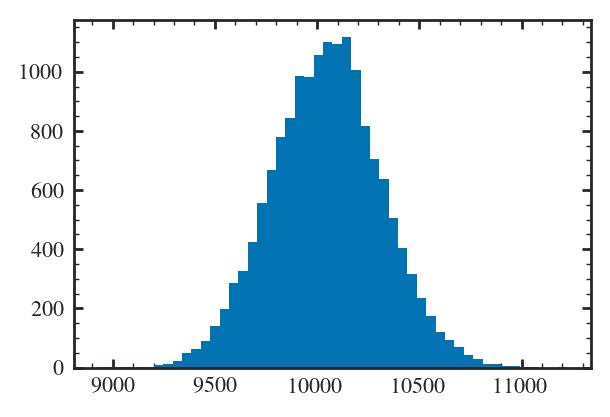

In [70]:
plt.hist(N_obs_samples)

In [59]:
len(N_obs_samples)

16000

In [71]:
find_mass(np.median(N_obs_samples), num_stars=1e6)

(np.int64(590995), np.float64(170837.47711442562), <Quantity -7.65857288>)

(array([1.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.000e+00,
        8.000e+00, 1.200e+01, 2.300e+01, 4.900e+01, 6.300e+01, 9.100e+01,
        1.390e+02, 1.990e+02, 2.860e+02, 3.260e+02, 4.250e+02, 5.550e+02,
        6.680e+02, 7.780e+02, 8.430e+02, 9.860e+02, 9.810e+02, 1.057e+03,
        1.100e+03, 1.095e+03, 1.119e+03, 1.006e+03, 8.170e+02, 7.040e+02,
        6.380e+02, 5.050e+02, 4.040e+02, 3.150e+02, 2.360e+02, 1.750e+02,
        1.210e+02, 9.200e+01, 6.800e+01, 4.100e+01, 2.800e+01, 1.300e+01,
        1.300e+01, 4.000e+00, 4.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 8925.64360541,  8971.59718962,  9017.55077383,  9063.50435805,
         9109.45794226,  9155.41152647,  9201.36511069,  9247.3186949 ,
         9293.27227911,  9339.22586333,  9385.17944754,  9431.13303175,
         9477.08661597,  9523.04020018,  9568.99378439,  9614.94736861,
         9660.90095282,  9706.85453703,  9752.80812125,  9798.76170546,
         9844.71

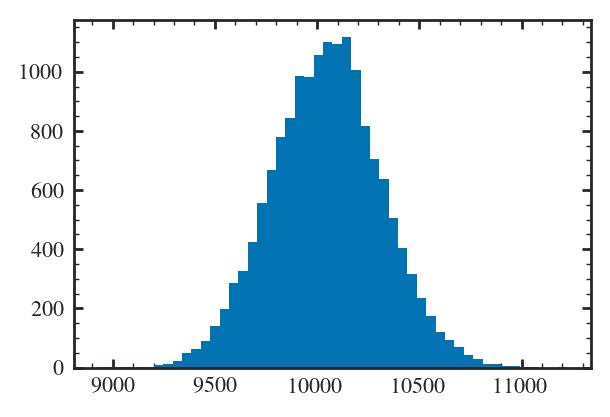

In [72]:
plt.hist(N_obs_samples)

In [73]:
masses, N_tot, abs_mags = sample_masses(N_obs_samples)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
plt.hist(np.log10(masses))
plt.axvline(np.log10(35_000))

(array([1., 0., 0., 0., 2., 1., 2., 1., 3., 0., 6., 5., 2., 5., 3., 3., 7.,
        8., 7., 7., 5., 7., 2., 4., 2., 1., 2., 1., 0., 0., 4., 0., 0., 1.,
        1., 1., 2., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([ 4480.  ,  5780.34,  7080.68,  8381.02,  9681.36, 10981.7 ,
        12282.04, 13582.38, 14882.72, 16183.06, 17483.4 , 18783.74,
        20084.08, 21384.42, 22684.76, 23985.1 , 25285.44, 26585.78,
        27886.12, 29186.46, 30486.8 , 31787.14, 33087.48, 34387.82,
        35688.16, 36988.5 , 38288.84, 39589.18, 40889.52, 42189.86,
        43490.2 , 44790.54, 46090.88, 47391.22, 48691.56, 49991.9 ,
        51292.24, 52592.58, 53892.92, 55193.26, 56493.6 , 57793.94,
        59094.28, 60394.62, 61694.96, 62995.3 , 64295.64, 65595.98,
        66896.32, 68196.66, 69497.  ]),
 <BarContainer object of 50 artists>)

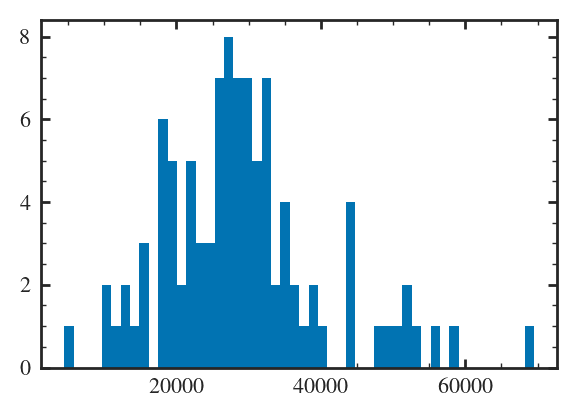

In [62]:
plt.hist(N_tot)

In [63]:
np.quantile(N_tot, [0.16, 0.5, 0.84])

array([19053.36, 28156.5 , 37960.68])

In [64]:
np.quantile(masses, [0.16, 0.5, 0.84])

array([ 5679.4977956 ,  8359.4243321 , 11119.70488113])

In [65]:
np.median(masses) / 2

np.float64(4179.712166051615)

In [66]:
src.num_stars

28156

In [26]:
src.total_mag("DECam_g") - 5*np.log10(distance / (10*u.pc)) - 2.5*np.log10(np.median(N_tot) / src.num_stars)



<Quantity -2.61073254>

# Gaia stars

In [29]:
mcmc_samples = Table.read("observations/bootes3/mcmc/samples.G_20.0.mcmc_plummer.csv")

In [30]:
N_obs_samples = mcmc_samples["N_memb"]

(array([ 1.,  0.,  3.,  4.,  4.,  6.,  7.,  8., 14., 18., 25., 28., 37.,
        45., 35., 51., 51., 42., 44., 51., 45., 61., 52., 44., 46., 30.,
        36., 26., 27., 27., 23., 18., 23., 15.,  9.,  9.,  5.,  2.,  8.,
         4.,  2.,  3.,  0.,  3.,  4.,  3.,  0.,  0.,  0.,  1.]),
 array([ 37.74620779,  40.03101152,  42.31581525,  44.60061898,
         46.88542271,  49.17022645,  51.45503018,  53.73983391,
         56.02463764,  58.30944137,  60.5942451 ,  62.87904883,
         65.16385256,  67.44865629,  69.73346002,  72.01826376,
         74.30306749,  76.58787122,  78.87267495,  81.15747868,
         83.44228241,  85.72708614,  88.01188987,  90.2966936 ,
         92.58149734,  94.86630107,  97.1511048 ,  99.43590853,
        101.72071226, 104.00551599, 106.29031972, 108.57512345,
        110.85992718, 113.14473091, 115.42953465, 117.71433838,
        119.99914211, 122.28394584, 124.56874957, 126.8535533 ,
        129.13835703, 131.42316076, 133.70796449, 135.99276822,
        138.

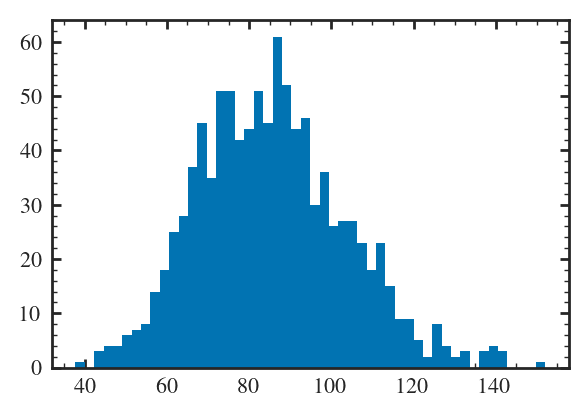

In [31]:
plt.hist(N_obs_samples)

In [32]:
find_mass(np.median(N_obs_samples), phot_system="Gaia", mag_limit=20, num_stars=1e5)

(np.int64(61399), np.float64(17817.398691063157), <Quantity -5.44430008>)

In [33]:
masses, N_tot, abs_mags = sample_masses(N_obs_samples, phot_system="Gaia", mag_limit=20, num_stars=2e5)


In [34]:
src = artpop.MISTSSP(
    log_age = 10.1,        # log of age in years
    feh = -2.0,           # metallicity [Fe/H]
    num_stars = np.median(N_tot),      # number of stars
    phot_system = 'DECam', # photometric system
    distance = 46 * u.kpc, # distance to system
    random_state = rng,   # random state for reproducibility
)


In [35]:
np.sum(src.mag_table["DECam_g"] < 23)

np.int64(810)

(24.0, 14.0)

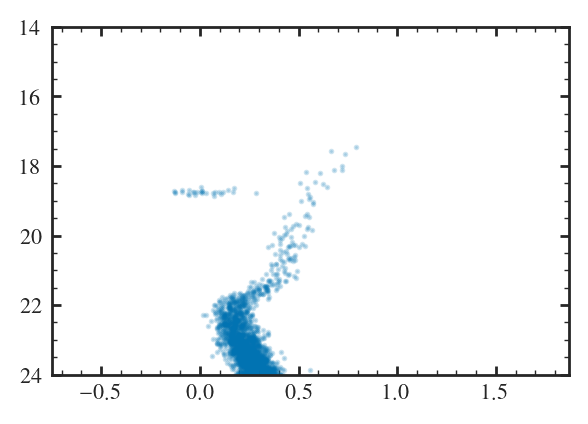

In [36]:
plt.scatter(src.mag_table["DECam_g"] - src.mag_table["DECam_r"] + 0.05*np.random.randn(len(src.mag_table)), src.mag_table["DECam_g"]+ 0.05*np.random.randn(len(src.mag_table)), s=1, alpha=0.2)

plt.ylim(24, 14)


(array([ 2.,  2.,  5.,  9.,  7., 10., 14.,  8., 13.,  8.,  6.,  2.,  5.,
         1.,  4.,  1.,  1.,  1.,  0.,  1.]),
 array([ 6854.60089898,  7956.74395668,  9058.88701438, 10161.03007208,
        11263.17312978, 12365.31618748, 13467.45924518, 14569.60230288,
        15671.74536057, 16773.88841827, 17876.03147597, 18978.17453367,
        20080.31759137, 21182.46064907, 22284.60370677, 23386.74676447,
        24488.88982217, 25591.03287987, 26693.17593756, 27795.31899526,
        28897.46205296]),
 <BarContainer object of 20 artists>)

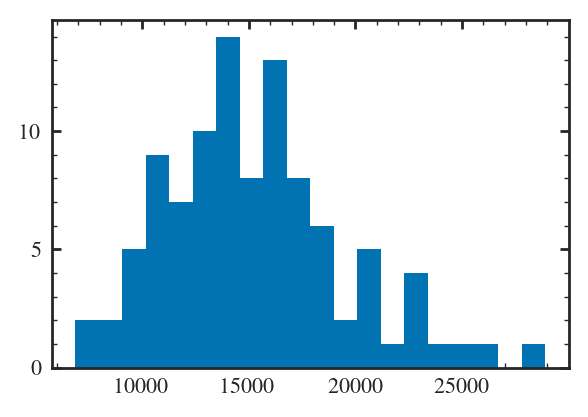

In [37]:
plt.hist(masses, bins=20)

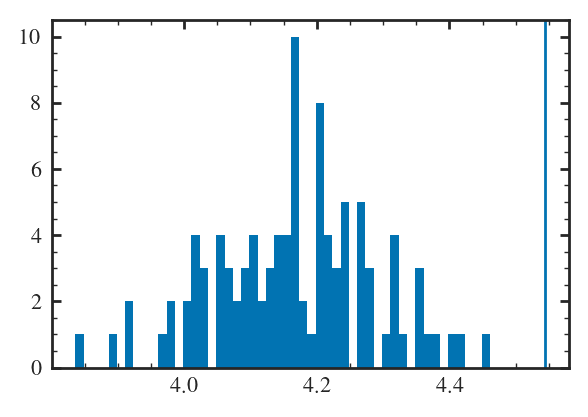

In [38]:
plt.hist(np.log10(masses))
plt.axvline(np.log10(35_000))

(array([ 1.,  3.,  1.,  3.,  4.,  9.,  8.,  9., 12.,  8.,  9.,  9.,  7.,
         4.,  6.,  2.,  1.,  1.,  1.,  2.]),
 array([-6.20720592, -6.12963092, -6.05205592, -5.97448092, -5.89690592,
        -5.81933093, -5.74175593, -5.66418093, -5.58660593, -5.50903093,
        -5.43145593, -5.35388093, -5.27630594, -5.19873094, -5.12115594,
        -5.04358094, -4.96600594, -4.88843094, -4.81085594, -4.73328095,
        -4.65570595]),
 <BarContainer object of 20 artists>)

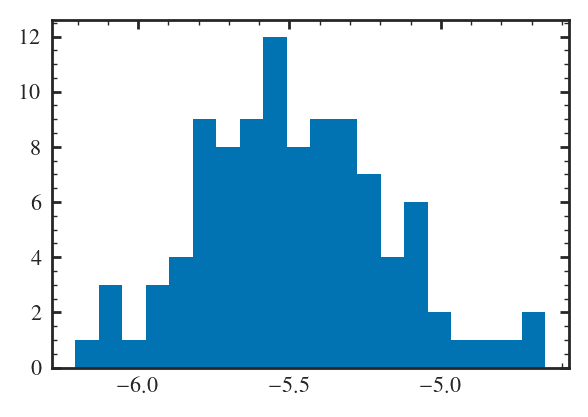

In [39]:
plt.hist(abs_mags, bins=20)

(array([ 2.,  2.,  5.,  8., 10.,  7., 12., 12., 11., 10.,  4.,  4.,  3.,
         4.,  1.,  2.,  1.,  1.,  0.,  1.]),
 array([22299.  , 26062.05, 29825.1 , 33588.15, 37351.2 , 41114.25,
        44877.3 , 48640.35, 52403.4 , 56166.45, 59929.5 , 63692.55,
        67455.6 , 71218.65, 74981.7 , 78744.75, 82507.8 , 86270.85,
        90033.9 , 93796.95, 97560.  ]),
 <BarContainer object of 20 artists>)

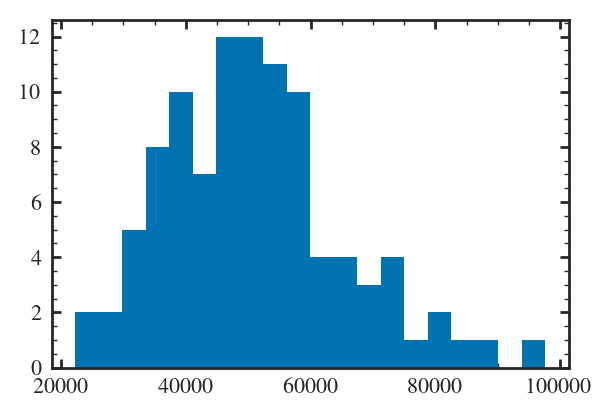

In [40]:
plt.hist(N_tot, bins=20)

## Gaia mag=21

In [42]:
mcmc_samples = Table.read("observations/bootes3/mcmc/samples.G_21.0.mcmc_plummer.csv")

In [43]:
N_obs_samples = mcmc_samples["N_memb"]

(array([ 1.,  2.,  4.,  4.,  9., 13., 10., 21., 31., 33., 35., 39., 36.,
        57., 46., 28., 55., 62., 57., 54., 50., 47., 48., 34., 33., 31.,
        20., 29., 30., 10., 12., 19., 12.,  5.,  5.,  3.,  3.,  1.,  1.,
         1.,  2.,  2.,  0.,  2.,  1.,  0.,  0.,  0.,  1.,  1.]),
 array([ 37.06698497,  39.67336194,  42.2797389 ,  44.88611586,
         47.49249282,  50.09886978,  52.70524674,  55.3116237 ,
         57.91800067,  60.52437763,  63.13075459,  65.73713155,
         68.34350851,  70.94988547,  73.55626244,  76.1626394 ,
         78.76901636,  81.37539332,  83.98177028,  86.58814724,
         89.1945242 ,  91.80090117,  94.40727813,  97.01365509,
         99.62003205, 102.22640901, 104.83278597, 107.43916294,
        110.0455399 , 112.65191686, 115.25829382, 117.86467078,
        120.47104774, 123.0774247 , 125.68380167, 128.29017863,
        130.89655559, 133.50293255, 136.10930951, 138.71568647,
        141.32206344, 143.9284404 , 146.53481736, 149.14119432,
        151.

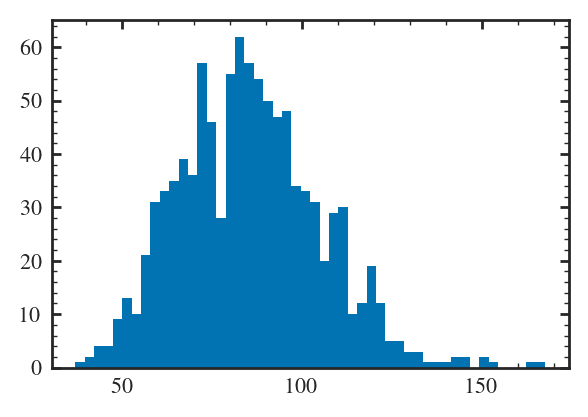

In [44]:
plt.hist(N_obs_samples)

In [ ]:
find_mass(np.median(N_obs_samples), phot_system="Gaia", mag_limit=21, num_stars=1e5)

In [46]:
masses, N_tot, abs_mags = sample_masses(N_obs_samples,
                                        phot_system="Gaia", mag_limit=21, num_stars=2e5)


In [47]:
src = artpop.MISTSSP(
    log_age = 10.1,        # log of age in years
    feh = -2.0,           # metallicity [Fe/H]
    num_stars = np.median(N_tot),      # number of stars
    phot_system = 'DECam', # photometric system
    distance = 46 * u.kpc, # distance to system
    random_state = rng,   # random state for reproducibility
)


In [48]:
np.sum(src.mag_table["DECam_g"] < 23)

np.int64(515)

(24.0, 14.0)

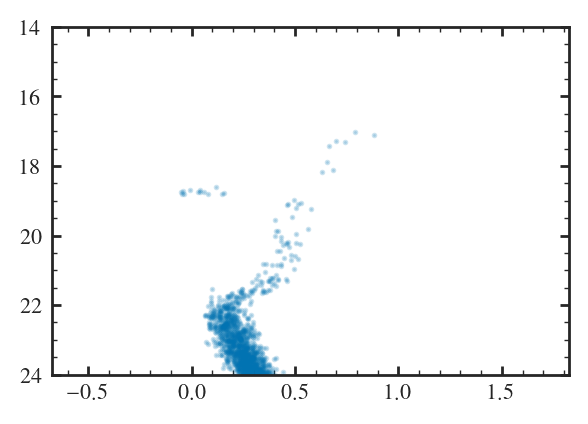

In [49]:
plt.scatter(src.mag_table["DECam_g"] - src.mag_table["DECam_r"] + 0.05*np.random.randn(len(src.mag_table)), src.mag_table["DECam_g"]+ 0.05*np.random.randn(len(src.mag_table)), s=1, alpha=0.2)

plt.ylim(24, 14)


(array([ 1.,  1.,  5.,  2., 11., 11.,  9., 21., 14.,  7.,  5.,  0.,  4.,
         3.,  2.,  1.,  2.,  0.,  0.,  1.]),
 array([ 1368.05765329,  2304.96046632,  3241.86327934,  4178.76609236,
         5115.66890538,  6052.5717184 ,  6989.47453142,  7926.37734444,
         8863.28015746,  9800.18297049, 10737.08578351, 11673.98859653,
        12610.89140955, 13547.79422257, 14484.69703559, 15421.59984861,
        16358.50266163, 17295.40547465, 18232.30828768, 19169.2111007 ,
        20106.11391372]),
 <BarContainer object of 20 artists>)

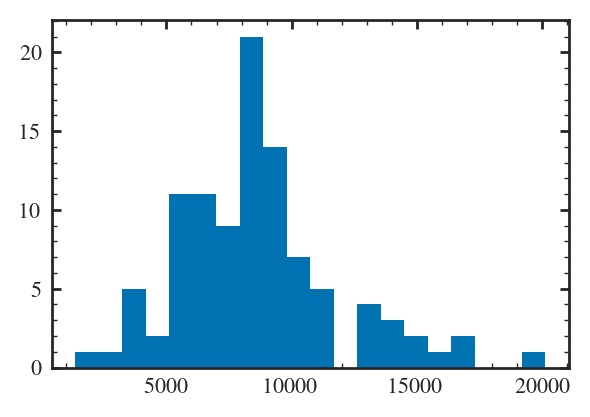

In [50]:
plt.hist(masses, bins=20)

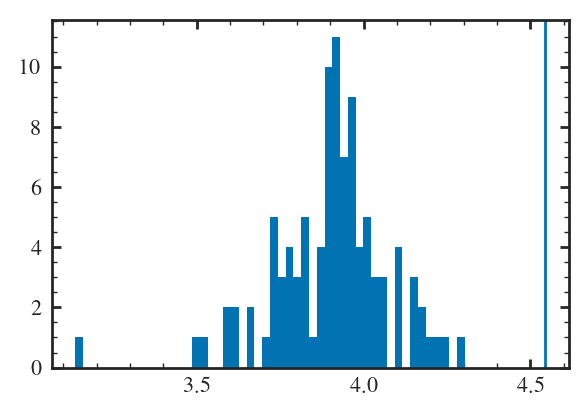

In [51]:
plt.hist(np.log10(masses))
plt.axvline(np.log10(35_000))

(array([ 2.,  1.,  6.,  4.,  9., 11.,  6., 14., 15., 14.,  5.,  4.,  2.,
         3.,  1.,  0.,  2.,  0.,  0.,  1.]),
 array([-5.72586896, -5.6099691 , -5.49406924, -5.37816938, -5.26226953,
        -5.14636967, -5.03046981, -4.91456995, -4.7986701 , -4.68277024,
        -4.56687038, -4.45097052, -4.33507067, -4.21917081, -4.10327095,
        -3.98737109, -3.87147124, -3.75557138, -3.63967152, -3.52377167,
        -3.40787181]),
 <BarContainer object of 20 artists>)

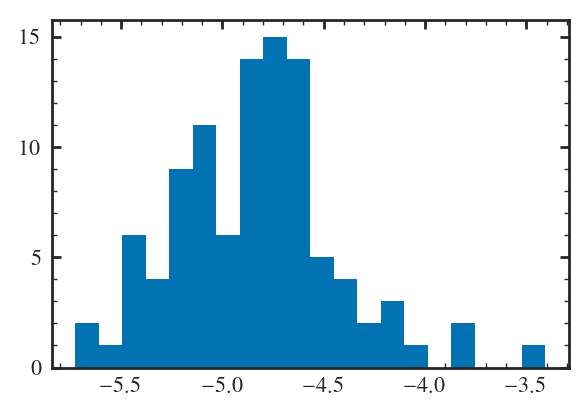

In [52]:
plt.hist(abs_mags, bins=20)

(array([ 1.,  2.,  4.,  3., 12.,  9., 15., 17., 14.,  6.,  4.,  0.,  4.,
         2.,  4.,  1.,  1.,  0.,  0.,  1.]),
 array([ 4480.  ,  7730.85, 10981.7 , 14232.55, 17483.4 , 20734.25,
        23985.1 , 27235.95, 30486.8 , 33737.65, 36988.5 , 40239.35,
        43490.2 , 46741.05, 49991.9 , 53242.75, 56493.6 , 59744.45,
        62995.3 , 66246.15, 69497.  ]),
 <BarContainer object of 20 artists>)

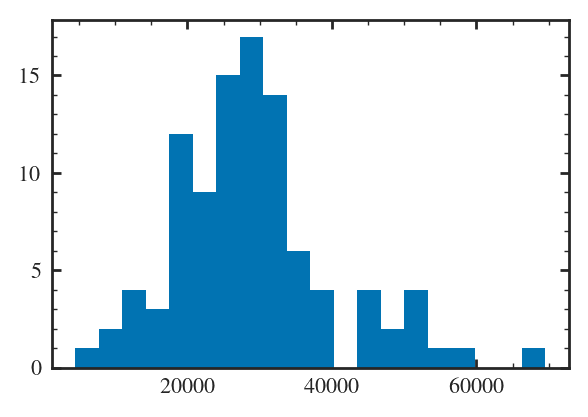

In [53]:
plt.hist(N_tot, bins=20)

(array([1., 0., 0., 1., 1., 3., 2., 0., 2., 3., 3., 1., 4., 3., 4., 3., 3.,
        1., 9., 6., 5., 2., 3., 2., 3., 9., 2., 4., 5., 0., 0., 4., 2., 1.,
        0., 2., 0., 3., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.]),
 array([0.93962741, 0.96675108, 0.99387475, 1.02099841, 1.04812208,
        1.07524575, 1.10236942, 1.12949309, 1.15661676, 1.18374042,
        1.21086409, 1.23798776, 1.26511143, 1.2922351 , 1.31935876,
        1.34648243, 1.3736061 , 1.40072977, 1.42785344, 1.45497711,
        1.48210077, 1.50922444, 1.53634811, 1.56347178, 1.59059545,
        1.61771912, 1.64484278, 1.67196645, 1.69909012, 1.72621379,
        1.75333746, 1.78046112, 1.80758479, 1.83470846, 1.86183213,
        1.8889558 , 1.91607947, 1.94320313, 1.9703268 , 1.99745047,
        2.02457414, 2.05169781, 2.07882148, 2.10594514, 2.13306881,
        2.16019248, 2.18731615, 2.21443982, 2.24156348, 2.26868715,
        2.29581082]),
 <BarContainer object of 50 artists>)

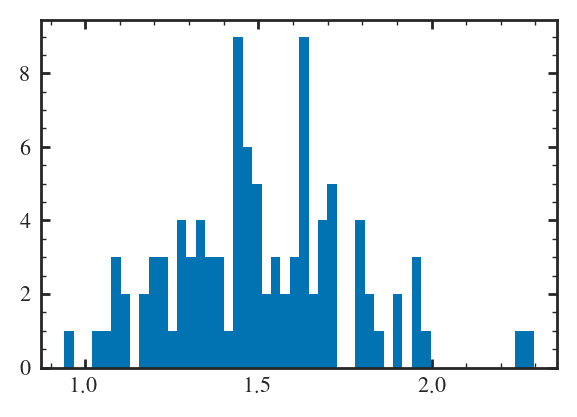

In [56]:
plt.hist(masses/ 10**(-0.4*(np.array(abs_mags) -4.5)))